# Training Deep Convolutional Neural Network
- Name1, Student's ID1
- Name2, Student's ID2

Name your file to (first 2 student ID digit)_(last 4 student ID digit)*4.ipynb

## Lab Instruction

In this lab, you will learn to train a deep convolutional neural network using Keras library with Tensorflow backend. We will use  Cat vs Dog dataset.

See https://www.kaggle.com/c/dogs-vs-cats/data


### Your Turn! Dog or Cat Application

Now, it time to put everything together and develop and Cat vs Dog classifier model. Assume that you and your company want to get more attraction on your product by launching a new product that can classify whether it is a dog or a cat. You have decide that you want a precision more than 90 - 95% in order to launch to product.

You have a cat and dog dataset contain total of 25000 images, 12500 for cat and other half for a dog.

After successfully develop this model, you can try to play with it to see how it perform. (You can upload your selfies image to see you are a dog or a cat)

Some note before start a project:
1. You have to load a data into a project using any method
**suggest**
   

```
 !wget -c https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
 !unzip -qq Cat_Dog_data.zip
```


2. You have to plan on how you will split a data. (or no need for suggest method)
3. You have to preprocess your data before feed into a network. For example, cropping, padding, etc.
4. You can come up with any model or use pre-train model. It depend on you!

You have two week for this project so that you can compete with your competitor app! Now, create a new Jupyter notebook and start building a model!

In [2]:
!wget -c https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
!unzip -qq Cat_Dog_data.zip

--2025-10-08 08:45:48--  https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.182.6, 52.217.117.192, 16.182.101.208, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.182.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 580495262 (554M) [application/zip]
Saving to: ‘Cat_Dog_data.zip’

Cat_Dog_data.zip    100%[===================>] 553.60M  20.9MB/s    in 29s     

2025-10-08 08:46:18 (18.9 MB/s) - ‘Cat_Dog_data.zip’ saved [580495262/580495262]



In [3]:
from tensorflow import keras
from keras import models
from keras import layers
from keras import optimizers
from keras import callbacks
from keras import backend as K
from keras.preprocessing import image
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.layers import MaxPooling2D, Conv2D
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# %load _utils
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from keras import backend as K

# Test
def print_hello():
    print('Hello')

# define a function to plot the result from training step
def show_result(history):

    # Print the result from the last epoch
    print('Last train accuracy: %s'%history.history['acc'][-1])
    print('Last validation accuracy: %s'%history.history['val_acc'][-1])

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    acc = history.history['acc']
    val_acc = history.history['val_acc']

    epochs = range(1, len(loss) + 1)

    # Define a subplot
    fig, axs = plt.subplots(1,2,figsize=(15,4))

    # Plot loss
    loss_plot = axs[0]

    loss_plot.plot(epochs, loss, 'c--', label='Training loss')
    loss_plot.plot(epochs, val_loss, 'b', label='Validation loss')
    loss_plot.set_title('Training and validation loss')
    loss_plot.set_xlabel('Epochs')
    loss_plot.set_ylabel('Loss')
    loss_plot.legend()

    # Plot accuracy
    acc_plot = axs[1]

    acc_plot.plot(epochs, acc, 'c--', label='Training acc')
    acc_plot.plot(epochs, val_acc, 'b', label='Validation acc')
    acc_plot.set_title('Training and validation accuracy')
    acc_plot.set_xlabel('Epochs')
    acc_plot.set_ylabel('Accuracy')
    acc_plot.legend()

# Define an evaluation function to print the evaluation result
def evaluation_report(model,features,labels):

    # Calculate result
    result = model.evaluate(features,labels,verbose=False)

    # Predict and convert into a class
    pred_class = model.predict(features).argmax(axis=1)
    labels = labels.argmax(axis=1)
    # Show report
    print(confusion_matrix(labels,pred_class))
    print(classification_report(labels,pred_class))
    print("Loss: %s Accuracy: %s" %(result[0],result[1]))

    return pred_class


# Show a subplot of the incorrect predict data
def show_false_prediction(predict, feature, label, img_size=28, channel=1):

    false_pred = feature[(predict != label).tolist()]
    actual_label = label[(predict != label).tolist()]
    false_label = predict[(predict != label).tolist()]
    if channel == 3:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size,channel)
    elif channel == 1:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size)
    else:
        raise ValueError('Must be RGB or gray scale image')

    print(false_pred.shape)

    fig, ax = plt.subplots(3,10,figsize=(15,6))
    fig.suptitle('The incorrect prediction')

    for i in range(3):
        for j in range(10):
            ax[i,j].imshow(false_pred[j + i*10],cmap='gray')
            ax[i,j].set_title('Pred %s Act %s'%(false_label[j + i*10],actual_label[j + i*10]))

# Show activation value of each layer
def show_layer_activation(activation, model,num_layer,num_row=16):
    layer_names = []
    for layer in model.layers[:num_layer]:
        layer_names.append(layer.name)

    images_per_row = num_row
    for layer_name, layer_activation in zip(layer_names,activation):
        n_features = layer_activation.shape[-1]

        size = layer_activation.shape[1]

        n_cols = n_features//images_per_row
        display_grid = np.zeros((size * n_cols, images_per_row * size))

        for col in range(n_cols):
            for row in range(images_per_row):
                channel_image = layer_activation[0,:,:,col*images_per_row + row]
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0,255).astype('uint8')
                display_grid[col*size:(col +1)*size,
                             row*size:(row+1)*size] = channel_image
        scale = 1./size
        plt.figure(figsize=(scale*display_grid.shape[1],
                           scale*display_grid.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')


def deprocess_image(img):

    # Zero-centering and make sure that std is 0.1
    img -= img.mean()
    img /= (img.std() + 1e-5)
    img *= 0.1

    # Clips to [0,1]
    img += 0.5
    img = np.clip(img,0,1)

    # Convert to RGB array
    img *= 255
    img = np.clip(img,0,255).astype('uint8')

    return img

def generate_pattern(model, layer_name , filter_index, size=150):
    # Build the loss function that maximize the activation of the nth filter of the layer under consideration
    layer_output = model.get_layer(layer_name).output
    loss = K.mean(layer_output[:,:,:,filter_index])

    # Compute the gradient of the input picture with regard to this loss
    grads = K.gradients(loss, model.input)[0]

    # Normalize the gradient
    grads /= (K.sqrt(K.mean(K.square(grads))) +1e-5)

    # Return the loss and gradient given the input picture
    iterate = K.function([model.input],[loss, grads])

    # Stars from a gray image with some noise
    input_img_data = np.random.random((1, size, size, 3)) * 20 + 128.

    # Run gradient ascent for 40 step
    step = 1.
    for i in range(40):
        loss_value, grads_value = iterate([input_img_data])
        input_img_data += grads_value * step

    img = input_img_data[0]
    return deprocess_image(img)

### feed layer name. ie, 'conv_1'
def visualize_filter(model,layer_name, size= 64, margin = 5):

    # Empty black image to store results
    results = np.zeros((8 * size + 7 * margin, 8 * size + 7 * margin, 3))

    # iterate over the row of result grid
    for i in range(8):
        # Iterate over the column of the result grid
        for j in range(8):
            # Generates the pattern for filter i + (j*8) in layer_name
            filter_img = generate_pattern(model, layer_name, i + (j*8), size=size)

            # Puts the result in the square (i,j) of the results grid
            horizontal_start = i * size + i * margin
            horizontal_end = horizontal_start + size
            vertical_start = j * size + j * margin
            vertical_end = vertical_start + size
            results[horizontal_start:horizontal_end,
                    vertical_start:vertical_end, :] = filter_img

    plt.figure(figsize=(20,20))
    plt.imshow(results)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.datasets import cifar10

In [7]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# Load CIFAR-10 and filter cat vs dog
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [9]:
# Class 3=cat, 5=dog
chosen = [3, 5]
train_mask = np.isin(y_train_full, chosen)
test_mask = np.isin(y_test_full, chosen)

In [10]:
x_train_cd = x_train_full[train_mask]
y_train_cd = y_train_full[train_mask]
x_test_cd = x_test_full[test_mask]
y_test_cd = y_test_full[test_mask]

In [11]:
# Map labels: 3->0 (cat), 5->1 (dog)
y_train_cd = (y_train_cd == 5).astype(np.int32)
y_test_cd = (y_test_cd == 5).astype(np.int32)

In [12]:
# Normalize to [0,1]
x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

In [13]:
# Train/validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_cd, y_train_cd, test_size=0.2, random_state=42, stratify=y_train_cd
)

In [14]:
input_shape = x_train.shape[1:]  # (32,32,3)
print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test_cd.shape, y_test_cd.shape)

Train: (8000, 32, 32, 3) (8000,)
Val  : (2000, 32, 32, 3) (2000,)
Test : (2000, 32, 32, 3) (2000,)


In [15]:
# Enhanced data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

Enhanced Model Architecture

* **Deeper network**: Added more convolutional blocks (3 blocks with 64→128→256 filters)
* **Batch Normalization**: Added after each Conv2D layer for faster training and better generalization
* **Double Conv layers**: Each block has 2 Conv2D layers before pooling for better feature extraction
* **Improved Dense layers**: 2 Dense layers with BatchNorm for better classification

In [16]:
# Improved model architecture
def build_improved_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(256, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="improved_cat_dog_cnn")
    return model

model = build_improved_model(input_shape)
model.summary()

Model: "improved_cat_dog_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,83

 Total params: 2,232,385 (8.52 MB)

 Trainable params: 2,229,825 (8.51 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [17]:
# Compile with optimized settings
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)

In [23]:
# Enhanced callbacks
callbacks_list = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=False, # Changed to False
        verbose=1
    ),
    ModelCheckpoint(
        "best_catdog_optimized.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [24]:
# Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.8765 - loss: 0.2994 - precision: 0.8933 - recall: 0.8619
Epoch 1: val_accuracy improved from -inf to 0.84350, saving model to best_catdog_optimized.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 214s 852ms/step - accuracy: 0.8765 - loss: 0.2993 - precision: 0.8933 - recall: 0.8620 - val_accuracy: 0.8435 - val_loss: 0.3628 - val_precision: 0.8643 - val_recall: 0.8150 - learning_rate: 3.1250e-05
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.8797 - loss: 0.2821 - precision: 0.8962 - recall: 0.8653
Epoch 2: val_accuracy did not improve from 0.84350
250/250 ━━━━━━━━━━━━━━━━━━━━ 205s 819ms/step - accuracy: 0.8797 - loss: 0.2821 - precision: 0.8962 - recall: 0.8653 - val_accuracy: 0.8435 - val_loss: 0.3609 - val_precision: 0.8635 - val_recall: 0.8160 - learning_rate: 3.1250e-05
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8773 - loss: 0.2798 - precision: 0.8924 - recall: 0.8649
Epoch 3: val_accuracy improved from 0.84350 to 0.84650, saving model to best_catdog_optimized.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 215s 859ms/step - accuracy: 0.8773 - loss: 0.2797 - precision: 0.8924 - recall: 0.8649 - val_accuracy: 0.8465 - val_loss: 0.3601 - val_precision: 0.8651 - val_recall: 0.8210 - learning_rate: 3.1250e-05
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8853 - loss: 0.2735 - precision: 0.8995 - recall: 0.8737
Epoch 4: val_accuracy did not improve from 0.84650
250/250 ━━━━━━━━━━━━━━━━━━━━ 251s 816ms/step - accuracy: 0.8853 - loss: 0.2734 - precision: 0.8995 - recall: 0.8737 - val_accuracy: 0.8440 - val_loss: 0.3716 - val_precision: 0.8731 - val_recall: 0.8050 - learning_rate: 3.1250e-05
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.8859 - loss: 0.2680 - precision: 0.8981 - recall: 0.8763
Epoch 5: val_accuracy improved from 0.84650 to 0.84700, saving model to best_catdog_optimized.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 214s 855ms/step - accuracy: 0.8859 - loss: 0.2680 - precision: 0.8980 - recall: 0.8763 - val_accuracy: 0.8470 - val_loss: 0.3651 - val_precision: 0.8676 - val_recall: 0.8190 - learning_rate: 3.1250e-05
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8897 - loss: 0.2572 - precision: 0.9032 - recall: 0.8790
Epoch 6: val_accuracy improved from 0.84700 to 0.84950, saving model to best_catdog_optimized.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 254s 821ms/step - accuracy: 0.8897 - loss: 0.2572 - precision: 0.9031 - recall: 0.8790 - val_accuracy: 0.8495 - val_loss: 0.3642 - val_precision: 0.8644 - val_recall: 0.8290 - learning_rate: 3.1250e-05
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8879 - loss: 0.2617 - precision: 0.8978 - recall: 0.8812
Epoch 7: val_accuracy did not improve from 0.84950
250/250 ━━━━━━━━━━━━━━━━━━━━ 206s 822ms/step - accuracy: 0.8879 - loss: 0.2617 - precision: 0.8978 - recall: 0.8813 - val_accuracy: 0.8470 - val_loss: 0.3659 - val_precision: 0.8676 - val_recall: 0.8190 - learning_rate: 3.1250e-05
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8917 - loss: 0.2586 - precision: 0.9023 - recall: 0.8844
Epoch 8: val_accuracy did not improve from 0.84950

Epoch 8: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
250/250 ━━━━━━━━━━━━━━━━━━━━ 213s 853ms/step - accuracy: 0.8917 - loss: 0.2586 - precision: 0.9022 - recall:

250/250 ━━━━━━━━━━━━━━━━━━━━ 206s 824ms/step - accuracy: 0.8922 - loss: 0.2559 - precision: 0.9033 - recall: 0.8841 - val_accuracy: 0.8510 - val_loss: 0.3597 - val_precision: 0.8604 - val_recall: 0.8380 - learning_rate: 1.5625e-05
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8885 - loss: 0.2551 - precision: 0.8994 - recall: 0.8810
Epoch 12: val_accuracy did not improve from 0.85100
250/250 ━━━━━━━━━━━━━━━━━━━━ 214s 858ms/step - accuracy: 0.8885 - loss: 0.2551 - precision: 0.8994 - recall: 0.8810 - val_accuracy: 0.8465 - val_loss: 0.3637 - val_precision: 0.8628 - val_recall: 0.8240 - learning_rate: 1.5625e-05
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.8897 - loss: 0.2587 - precision: 0.9019 - recall: 0.8805
Epoch 13: val_accuracy did not improve from 0.85100
250/250 ━━━━━━━━━━━━━━━━━━━━ 203s 814ms/step - accuracy: 0.8897 - loss: 0.2587 - precision: 0.9018 - recall: 0.8805 - val_accuracy: 0.8475 - val_loss: 0.3647 - val_precision: 0.8646 

In [25]:
# Evaluate on test set
test_metrics = model.evaluate(x_test_cd, y_test_cd, verbose=0)
print(f"\nTest Results:")
print(f"Loss: {test_metrics[0]:.4f}")
print(f"Accuracy: {test_metrics[1]:.4f}")
print(f"Precision: {test_metrics[2]:.4f}")
print(f"Recall: {test_metrics[3]:.4f}")


Test Results:
Loss: 0.3533
Accuracy: 0.8530
Precision: 0.8647
Recall: 0.8370


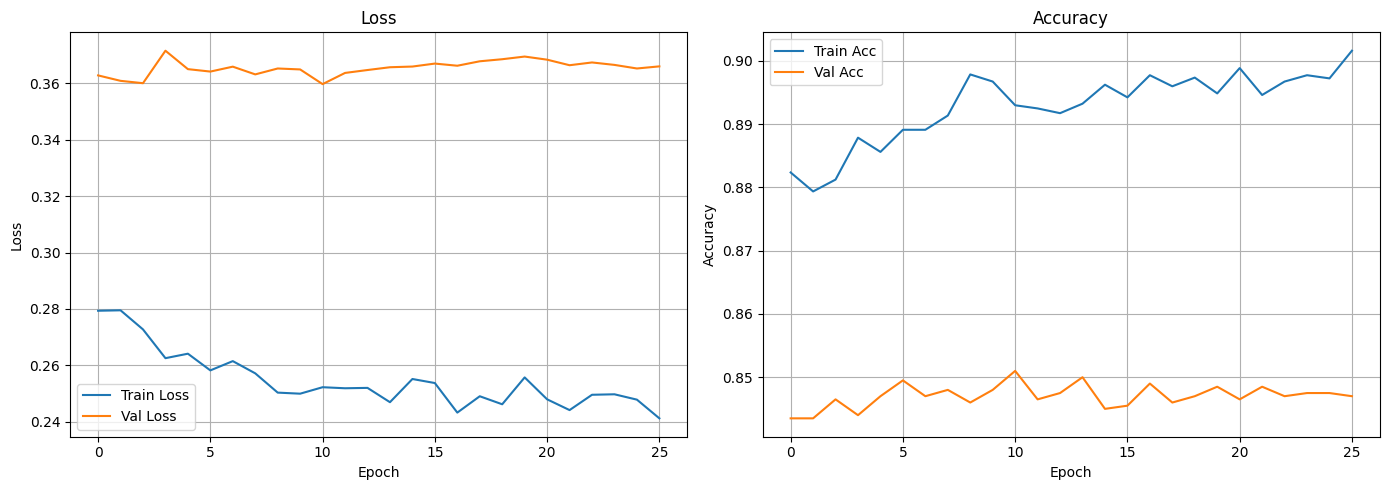

In [26]:
# Plot training history
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [27]:
# Predictions and classification report
y_prob = model.predict(x_test_cd, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cd, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_cd, y_pred, target_names=["cat(0)", "dog(1)"]))


Confusion Matrix:
[[869 131]
 [163 837]]

Classification Report:
              precision    recall  f1-score   support

      cat(0)       0.84      0.87      0.86      1000
      dog(1)       0.86      0.84      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

